# Aufgabe 3

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread

In [2]:
img = imread("duplo.png")

## 1.1

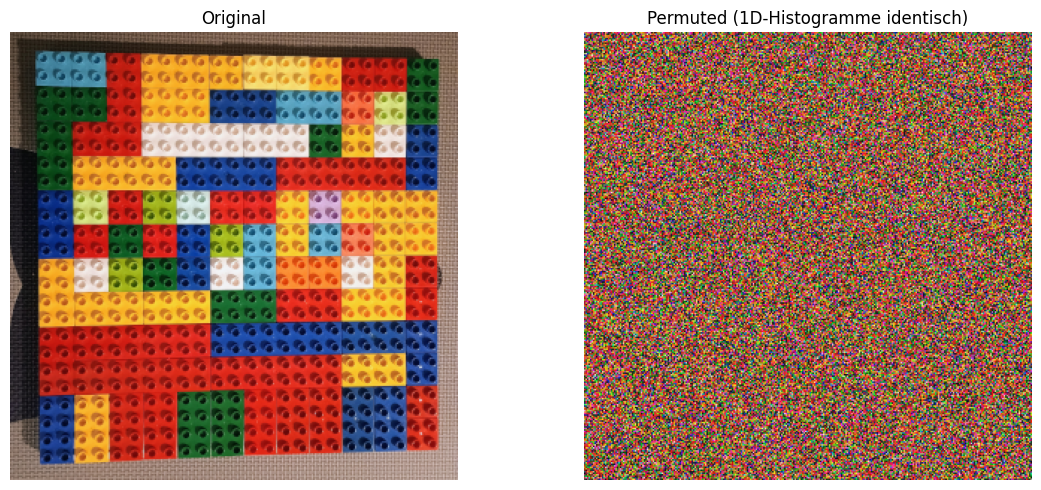

In [3]:
img_shuffled = img.copy()
h, w, c = img.shape

for i in range(c):
    # Konvertierung von 2D zu 1D Array, um shuffle zu verwenden
    channel = img[:, :, i].flatten()
    np.random.shuffle(channel)
    # Rückkonvertierung zu 2D 
    img_shuffled[:, :, i] = channel.reshape(h, w)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(img_shuffled)
axes[1].set_title("Shuffled (1D-Histogramme identisch)")
axes[1].axis('off')
plt.tight_layout()
plt.show()


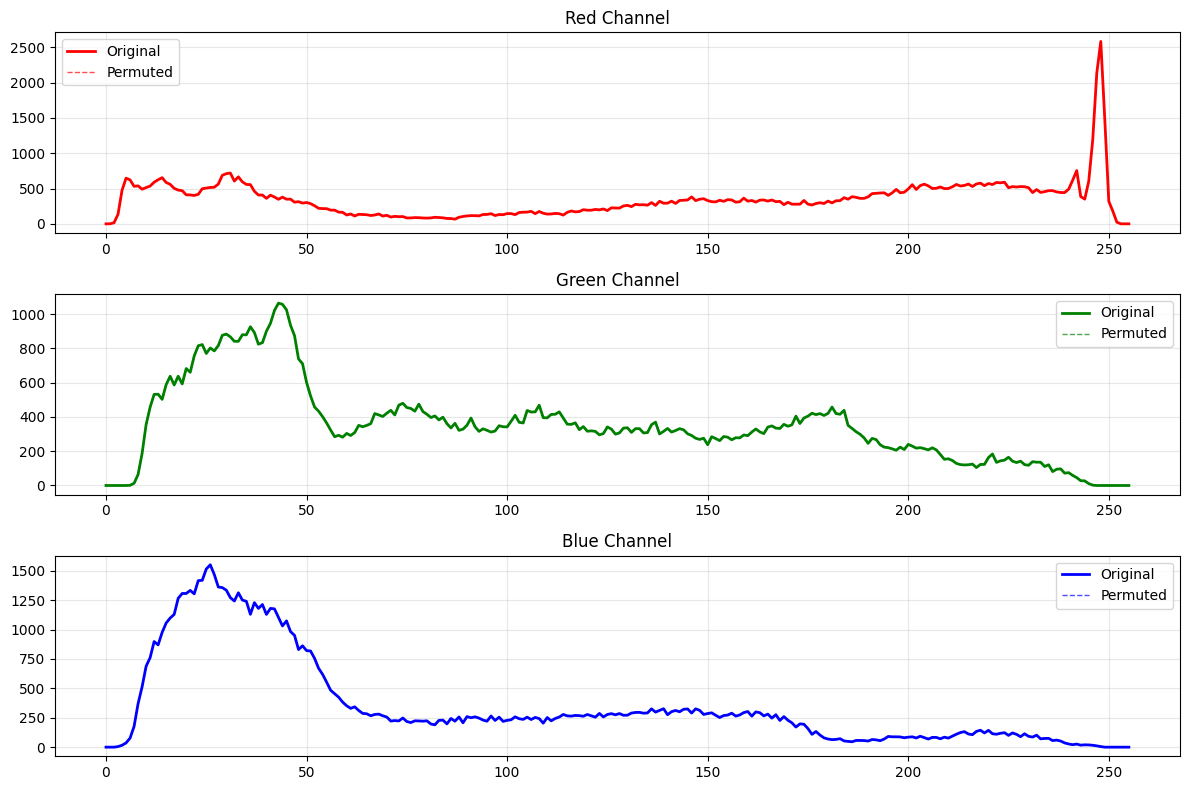

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
colors = ['red', 'green', 'blue']

for i in range(3):
    hist_orig, bins = np.histogram(img[:, :, i].flatten(), bins=256, range=(0, 256))
    hist_shuffled, _ = np.histogram(img_shuffled[:, :, i].flatten(), bins=256, range=(0, 256))
    
    axes[i].plot(hist_orig, color=colors[i], linewidth=2, label='Original')
    axes[i].plot(hist_shuffled, color=colors[i], linewidth=1, linestyle='--', alpha=0.7, label='Permuted')
    axes[i].set_title(f"{colors[i].capitalize()} Channel")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### <u>Hier haben wir bewusst Graphen verwendet, um zu zeigen, dass diese übereinander liegern und daraus folgt, dass die Histogramme gleich sind.</u>

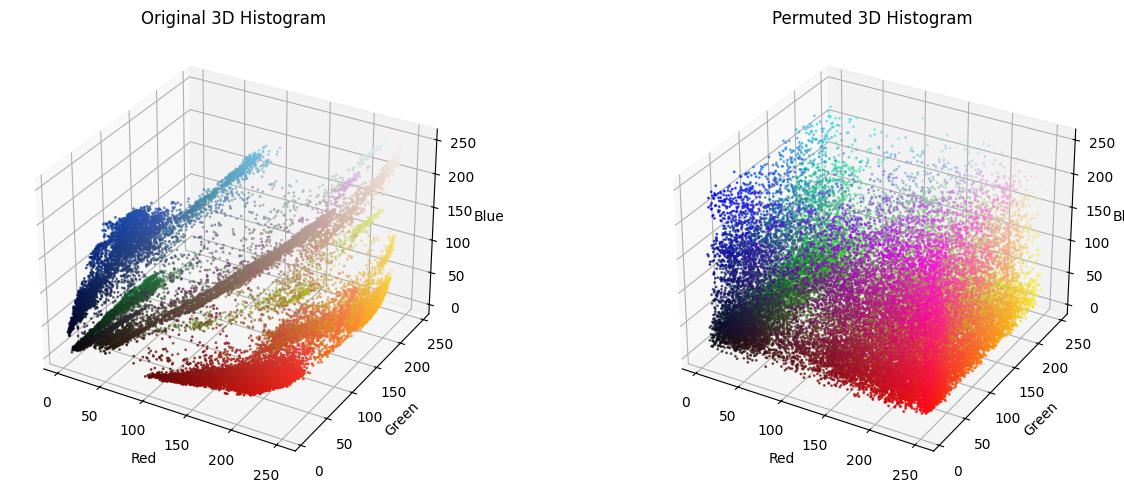

In [ ]:
fig = plt.figure(figsize=(14, 5))
images = [img, img_shuffled]
titles = ['Original 3D Histogram', 'Permuted 3D Histogram']

for idx, (image, title) in enumerate(zip(images, titles), 1):
    ax = fig.add_subplot(1, 2, idx, projection='3d')
    pixels = image.reshape(-1, 3)
    # Ein Drittel der Pixel zufällig auswählen
    half_size = pixels.shape[0] // 3
    sample = np.random.choice(pixels.shape[0], half_size, replace=False)
    pixels_sample = pixels[sample]
    colors_norm = pixels_sample / 255.0
    ax.scatter(pixels_sample[:, 0], pixels_sample[:, 1], pixels_sample[:, 2],
               c=colors_norm, s=1)
    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    ax.set_title(title)

plt.tight_layout()
plt.show()

#### <u>Wie wählen hier bewusst ein Drittel der Gesamtzahl der Pixel aus, dabei werden die Pixel zufällig gezogen. Wir nutzen nur ein Drittel, damit in den Histogrammen, vor allem im rechten alle Pixel sichtbar sind.</u>

# 1.2

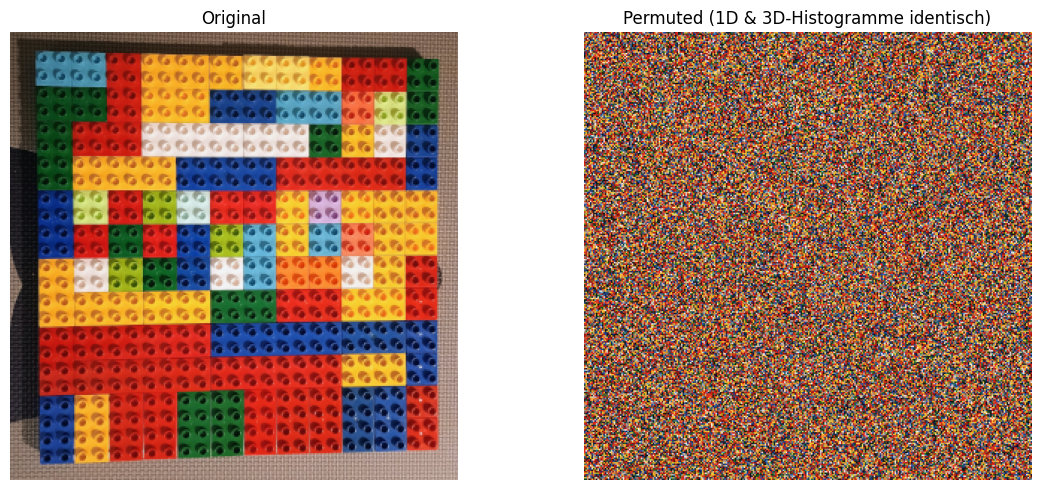

In [6]:
np.random.seed(42)
pixels = img.copy().reshape(-1, 3)
np.random.shuffle(pixels)
img_shuffled_3d = pixels.reshape(img.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(img_shuffled_3d)
axes[1].set_title("Permuted (1D & 3D-Histogramme identisch)")
axes[1].axis('off')
plt.tight_layout()
plt.show()


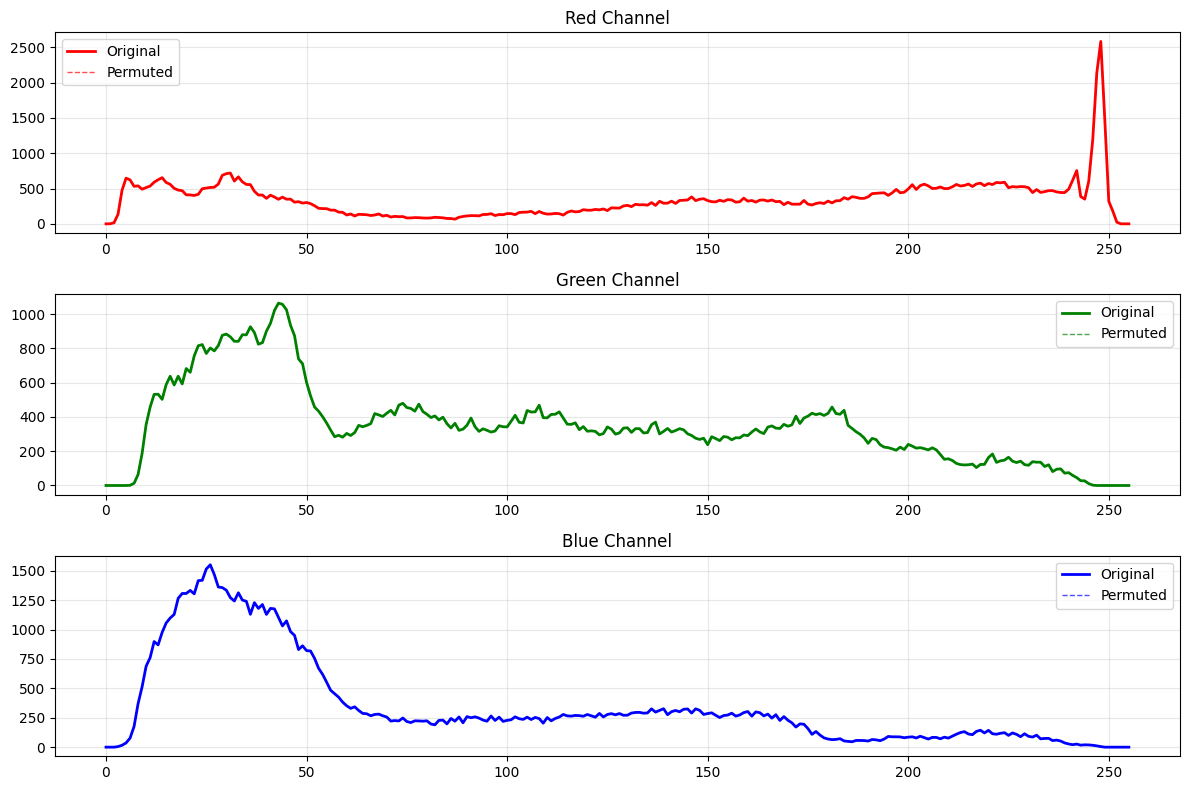

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
colors = ['red', 'green', 'blue']

for i in range(3):
    hist_orig, bins = np.histogram(img[:, :, i].flatten(), bins=256, range=(0, 256))
    hist_shuffled, _ = np.histogram(img_shuffled_3d[:, :, i].flatten(), bins=256, range=(0, 256))
    
    axes[i].plot(hist_orig, color=colors[i], linewidth=2, label='Original')
    axes[i].plot(hist_shuffled, color=colors[i], linewidth=1, linestyle='--', alpha=0.7, label='Permuted')
    axes[i].set_title(f"{colors[i].capitalize()} Channel")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()


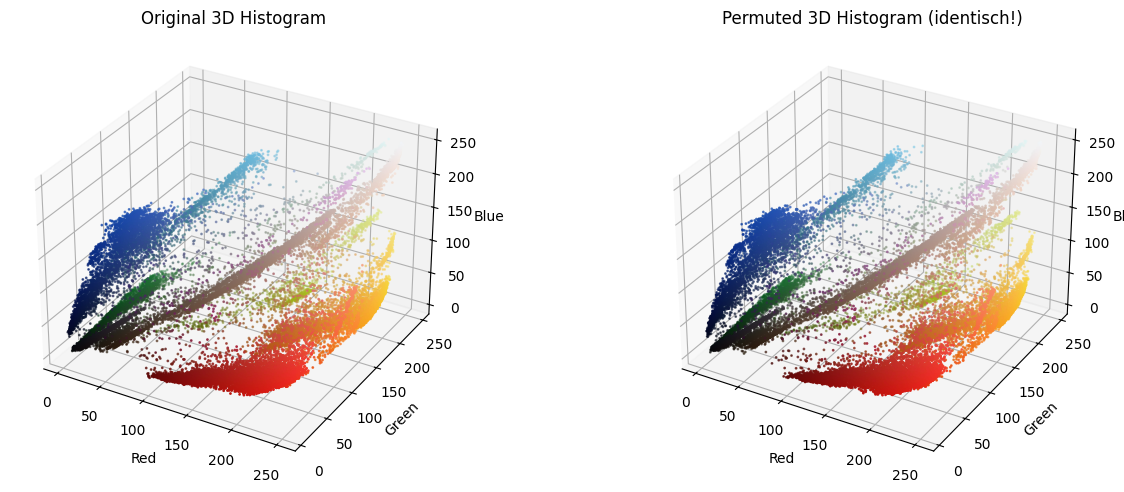

In [15]:
fig = plt.figure(figsize=(14, 5))
images = [img, img_shuffled_3d]
titles = ['Original 3D Histogram', 'Permuted 3D Histogram (identisch!)']

for idx, (image, title) in enumerate(zip(images, titles), 1):
    ax = fig.add_subplot(1, 2, idx, projection='3d')
    pixels = image.reshape(-1, 3)
    # Ein Drittel der Pixel zufällig auswählen
    half_size = pixels.shape[0] // 3
    sample = np.random.choice(pixels.shape[0], half_size, replace=False)
    pixels_sample = pixels[sample]
    colors_norm = pixels_sample / 255.0
    ax.scatter(pixels_sample[:, 0], pixels_sample[:, 1], pixels_sample[:, 2],
               c=colors_norm, s=1)
    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    ax.set_title(title)

plt.tight_layout()
plt.show()